In [1]:
import pandas as pd
import re
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion
from sklearn.metrics import accuracy_score

# ----------------------
# Load dataset
# ----------------------
df = pd.read_csv("Phishing_Email.csv")

# Clean columns
df = df.drop(columns=["Unnamed: 0"])
df = df.dropna()

df = df.rename(columns={
    "Email Text": "text",
    "Email Type": "label"
})

# Normalize labels
df["label"] = df["label"].str.lower()
df["label"] = df["label"].apply(lambda x: 1 if "phishing" in x else 0)

# ----------------------
# Text cleaning
# ----------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

# ----------------------
# Vectorizers
# ----------------------
word_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)   # unigrams + bigrams
)

char_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),  # detect typos like paypaI
    max_features=3000
)

# Combine both
X_word = word_vectorizer.fit_transform(df["clean_text"])
X_char = char_vectorizer.fit_transform(df["clean_text"])

from scipy.sparse import hstack
X = hstack([X_word, X_char])

y = df["label"]

# ----------------------
# Train-test split
# ----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------
# Train model
# ----------------------
model = MultinomialNB()
model.fit(X_train, y_train)

# ----------------------
# Evaluate
# ----------------------
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

# ----------------------
# Save everything
# ----------------------
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(word_vectorizer, open("word_vectorizer.pkl", "wb"))
pickle.dump(char_vectorizer, open("char_vectorizer.pkl", "wb"))

Accuracy: 0.946069224577408


In [3]:
import pickle
import re
from scipy.sparse import hstack

# Load
model = pickle.load(open("model.pkl", "rb"))
word_vectorizer = pickle.load(open("word_vectorizer.pkl", "rb"))
char_vectorizer = pickle.load(open("char_vectorizer.pkl", "rb"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

def predict_email(email):
    email = clean_text(email)

    X_word = word_vectorizer.transform([email])
    X_char = char_vectorizer.transform([email])

    X = hstack([X_word, X_char])

    pred = model.predict(X)[0]
    prob = model.predict_proba(X)[0]

    return {
        "prediction": "phishing" if pred == 1 else "safe",
        "confidence": max(prob)
    }

# Test
print(predict_email("heyy don't click me im spam"))

{'prediction': 'phishing', 'confidence': np.float64(0.5447095190010565)}


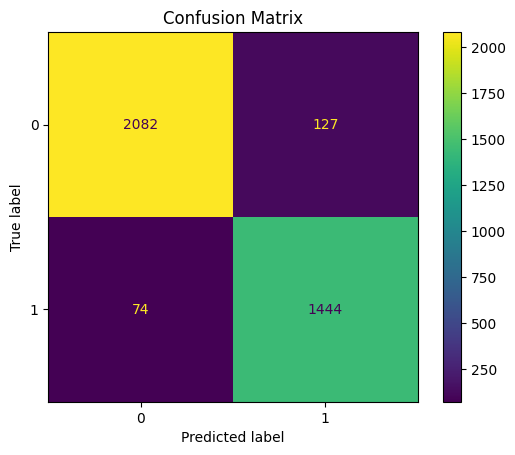

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [5]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95      2209
           1       0.92      0.95      0.93      1518

    accuracy                           0.95      3727
   macro avg       0.94      0.95      0.94      3727
weighted avg       0.95      0.95      0.95      3727



In [6]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

Accuracy: 0.946069224577408


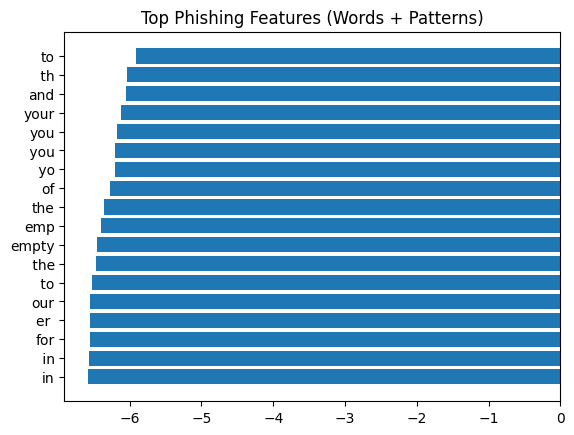

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Get feature names
word_features = word_vectorizer.get_feature_names_out()
char_features = char_vectorizer.get_feature_names_out()

# Combine them
all_features = np.concatenate([word_features, char_features])

# Get phishing class probabilities
log_probs = model.feature_log_prob_[1]

# Get top 20 important features
top_indices = np.argsort(log_probs)[-20:]

top_words = [all_features[i] for i in top_indices]

# Plot
plt.figure()
plt.barh(top_words, log_probs[top_indices])
plt.title("Top Phishing Features (Words + Patterns)")
plt.show()

In [9]:
log_probs_word = model.feature_log_prob_[1][:len(word_features)]

top_idx_word = np.argsort(log_probs_word)[-15:]
top_words_only = [word_features[i] for i in top_idx_word]

In [10]:
log_probs_char = model.feature_log_prob_[1][len(word_features):]

top_idx_char = np.argsort(log_probs_char)[-15:]
top_chars_only = [char_features[i] for i in top_idx_char]

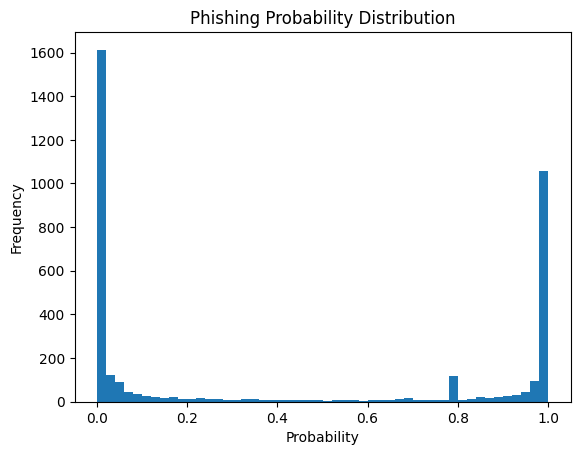

In [11]:
probs = model.predict_proba(X_test)

plt.hist(probs[:,1], bins=50)
plt.title("Phishing Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

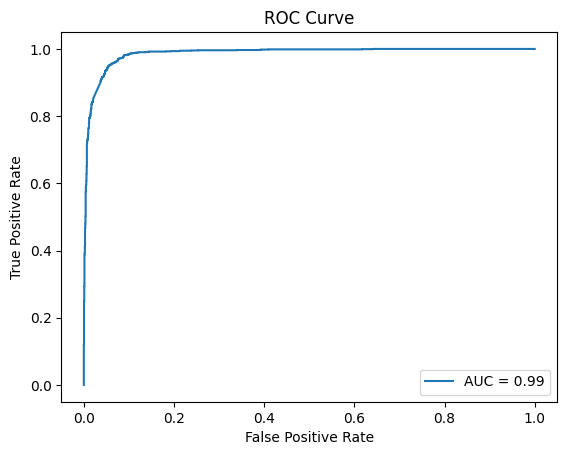

In [12]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, probs[:,1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

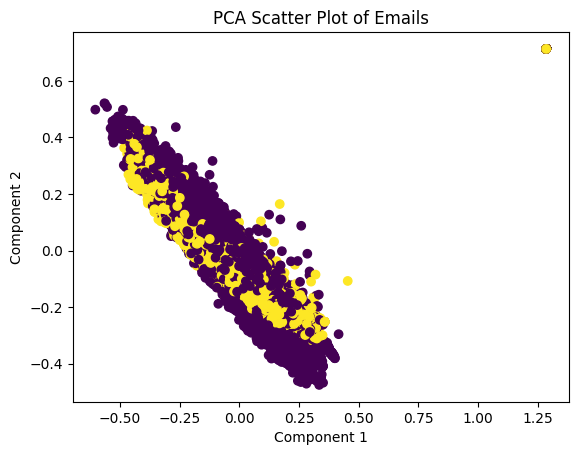

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

# Scatter plot
plt.figure()
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y)
plt.title("PCA Scatter Plot of Emails")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

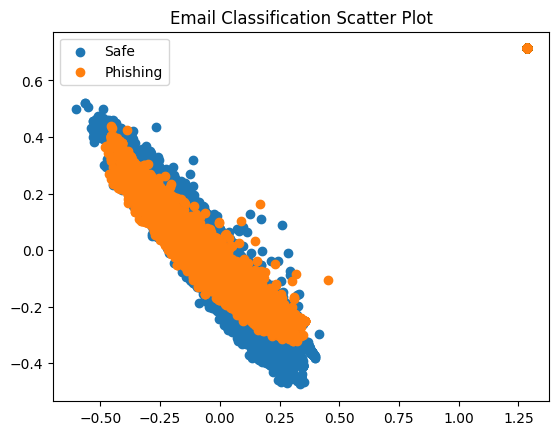

In [14]:
plt.figure()

plt.scatter(X_reduced[y == 0, 0], X_reduced[y == 0, 1], label="Safe")
plt.scatter(X_reduced[y == 1, 0], X_reduced[y == 1, 1], label="Phishing")

plt.legend()
plt.title("Email Classification Scatter Plot")
plt.show()

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X.toarray())

plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)
plt.title("t-SNE Visualization")
plt.show()

In [ ]:
plt.figure()

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=pred)
plt.title("Model Predictions Visualization")
plt.show()